# Ridge Regression: Regularizace s L2 penalizací

## Co je Ridge Regression?

Ridge Regression (hřebenová regrese) je metoda lineární regrese, která používá L2 regularizaci pro řešení problémů multikolinearity a přeučení. Metoda přidává "penalizaci" k běžné metodě nejmenších čtverců, která omezuje velikost koeficientů modelu.

### Matematická formulace:

Ridge Regression minimalizuje následující funkci:

$$\min_{\beta} \|y - X\beta\|^2_2 + \alpha \|\beta\|^2_2$$

kde:
- $y$ je vektor cílových hodnot
- $X$ je matice příznaků
- $\beta$ jsou koeficienty modelu
- $\alpha$ je regularizační parametr (síla penalizace)
- $\|\beta\|^2_2$ je L2 norma koeficientů (suma čtverců)

### Klíčové vlastnosti Ridge Regression:

1. **Penalizace velkých koeficientů**: Ridge zmenšuje koeficienty modelu, ale nikdy je nenastaví přesně na nulu
2. **Řešení multikolinearity**: Efektivně zvládá korelované příznaky
3. **Prevence přeučení**: Omezení velikosti koeficientů snižuje složitost modelu
4. **Numerická stabilita**: Poskytuje stabilní řešení i v případech, kdy standardní lineární regrese selhává

### Kdy použít Ridge Regression:

- Když máte mnoho korelovaných příznaků
- Když potřebujete zmírnit přeučení modelu
- Když chcete zlepšit stabilitu a předvídací schopnost modelu
- Když chcete zachovat všechny příznaky v modelu (na rozdíl od Lasso, které některé vypustí)

Pojďme si ukázat, jak Ridge Regression funguje v praxi pomocí scikit-learn!

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression, Lasso, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression, fetch_california_housing, load_diabetes
import time

# Nastavení vizualizací
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('muted')

# Pro reprodukovatelnost výsledků
np.random.seed(42)

## 1. Demonstrace základního principu Ridge Regression

Nejprve vytvoříme syntetický dataset, který nám pomůže pochopit, jak funguje Ridge Regression. Vytvoříme data s multikolinearitou (silně korelovanými příznaky), kde bude standardní lineární regrese nestabilní.

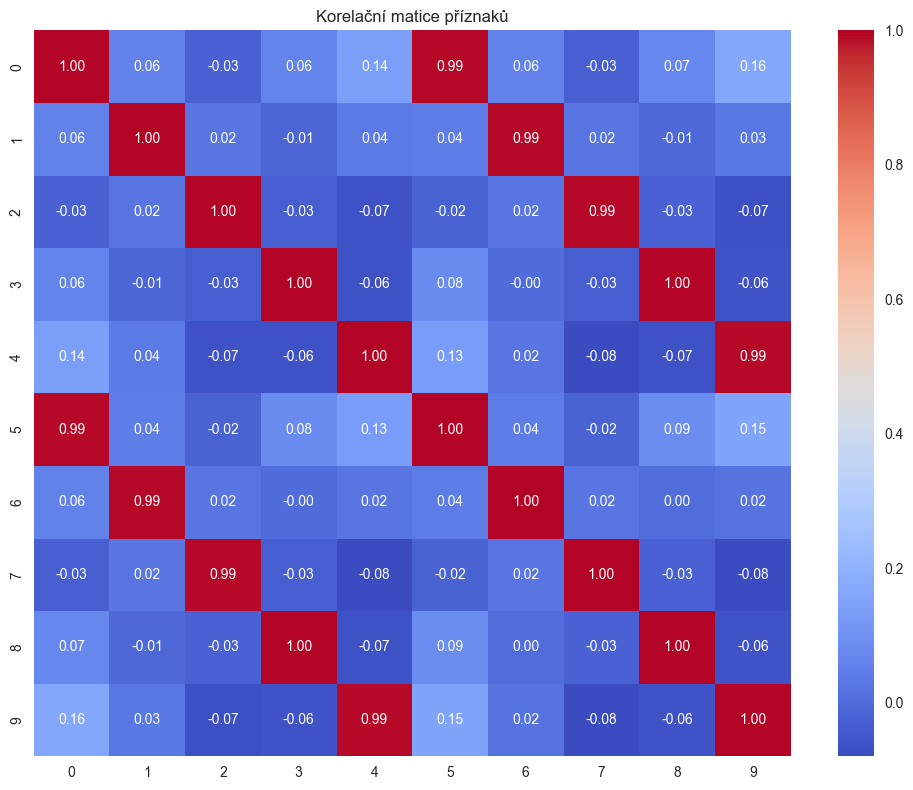

In [2]:
# Vytvoření syntetického datasetu s multikolinearitou
def create_multicollinear_data(n_samples=100, n_features=10, noise=10, random_state=42):
    """Vytvoří dataset se silně korelovanými příznaky"""
    X, y = make_regression(n_samples=n_samples, 
                         n_features=n_features, 
                         n_informative=n_features, 
                         noise=noise, 
                         random_state=random_state)
    
    # Přidání silné korelace mezi některými příznaky
    rng = np.random.RandomState(random_state)
    for i in range(n_features // 2, n_features):
        X[:, i] = X[:, i % (n_features // 2)] + rng.normal(0, 0.1, n_samples)
    
    return X, y

# Vytvoření datasetu
X, y = create_multicollinear_data(n_samples=100, n_features=10, noise=20)

# Rozdělení na trénovací a testovací data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Kontrola korelace mezi příznaky
correlation_matrix = np.corrcoef(X.T)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelační matice příznaků')
plt.tight_layout()
plt.show()

In [3]:
# Standardizace příznaků
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trénování modelů s různými hodnotami alpha
alphas = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_models = {}
coef_paths = []

for alpha in alphas:
    if alpha == 0:
        # Alpha=0 odpovídá standardní lineární regresi
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)
    
    # Trénování modelu
    model.fit(X_train_scaled, y_train)
    
    # Uložení modelu a koeficientů
    ridge_models[alpha] = model
    coef_paths.append(model.coef_)
    
    # Výpočet metriky na testovacích datech
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Alpha = {alpha}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  L2 norma koeficientů: {np.linalg.norm(model.coef_):.4f}")

Alpha = 0:
  MSE: 34193.3801
  R²: 0.3002
  L2 norma koeficientů: 276.3468
Alpha = 0.01:
  MSE: 34172.9559
  R²: 0.3006
  L2 norma koeficientů: 271.1720
Alpha = 0.1:
  MSE: 34042.0014
  R²: 0.3033
  L2 norma koeficientů: 234.1018
Alpha = 1.0:
  MSE: 33784.4333
  R²: 0.3086
  L2 norma koeficientů: 127.4717
Alpha = 10.0:
  MSE: 33022.3515
  R²: 0.3242
  L2 norma koeficientů: 88.0872
Alpha = 100.0:
  MSE: 33287.3184
  R²: 0.3187
  L2 norma koeficientů: 52.0905


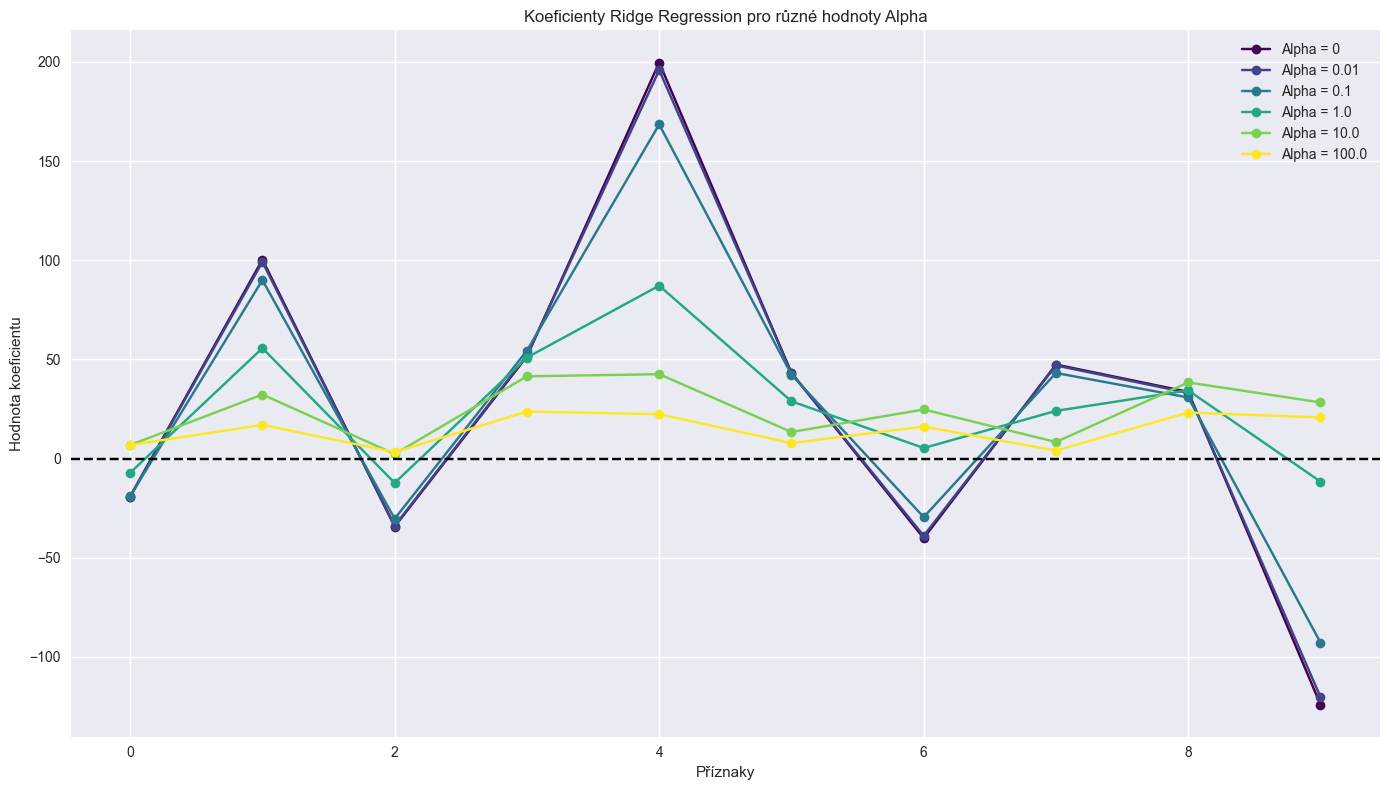

In [4]:
# Vizualizace koeficientů pro různé hodnoty alpha
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))

for i, (alpha, color) in enumerate(zip(alphas, colors)):
    plt.plot(range(X_train.shape[1]), coef_paths[i], 'o-', color=color, 
             label=f'Alpha = {alpha}')

plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Příznaky')
plt.ylabel('Hodnota koeficientu')
plt.title('Koeficienty Ridge Regression pro různé hodnoty Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

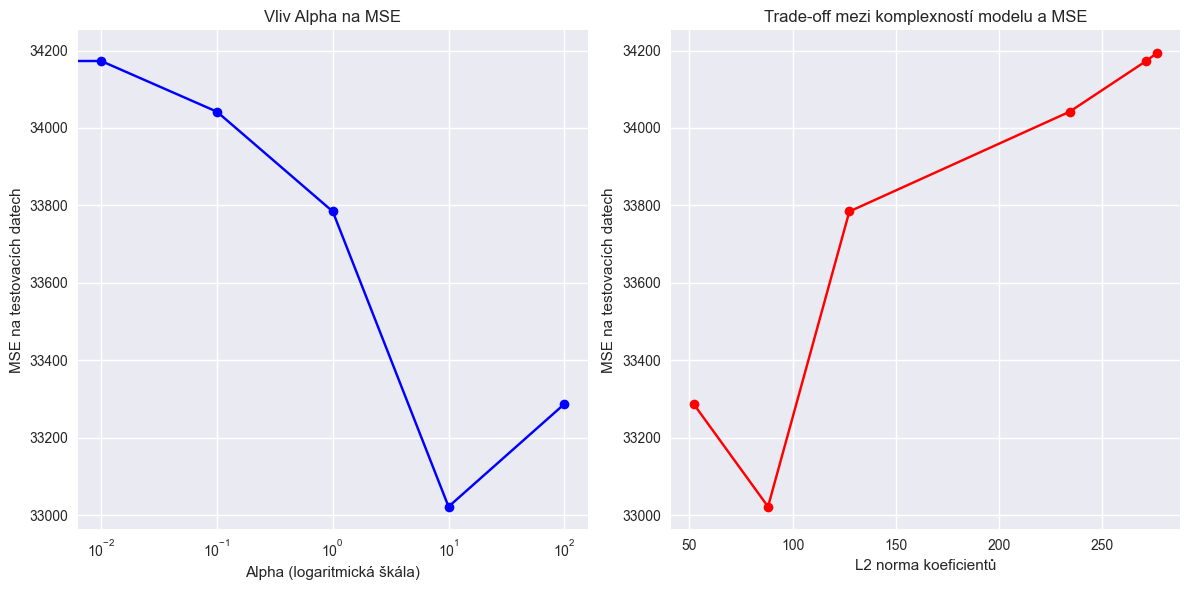

In [5]:
# Vizualizace L2 normy koeficientů vs. MSE pro různé hodnoty alpha
mse_scores = []
norms = []

for alpha in alphas:
    model = ridge_models[alpha]
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    norm = np.linalg.norm(model.coef_)
    
    mse_scores.append(mse)
    norms.append(norm)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, mse_scores, 'o-', color='blue')
plt.xscale('log')
plt.xlabel('Alpha (logaritmická škála)')
plt.ylabel('MSE na testovacích datech')
plt.title('Vliv Alpha na MSE')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(norms, mse_scores, 'o-', color='red')
plt.xlabel('L2 norma koeficientů')
plt.ylabel('MSE na testovacích datech')
plt.title('Trade-off mezi komplexností modelu a MSE')
plt.grid(True)

plt.tight_layout()
plt.show()

## 2. Ridge Regression na reálných datech

Nyní vyzkoušíme Ridge Regression na reálném datasetu. Použijeme dataset California Housing, který obsahuje informace o cenách domů v Kalifornii.

Tvar datasetu: (20640, 8)
Příznaky: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


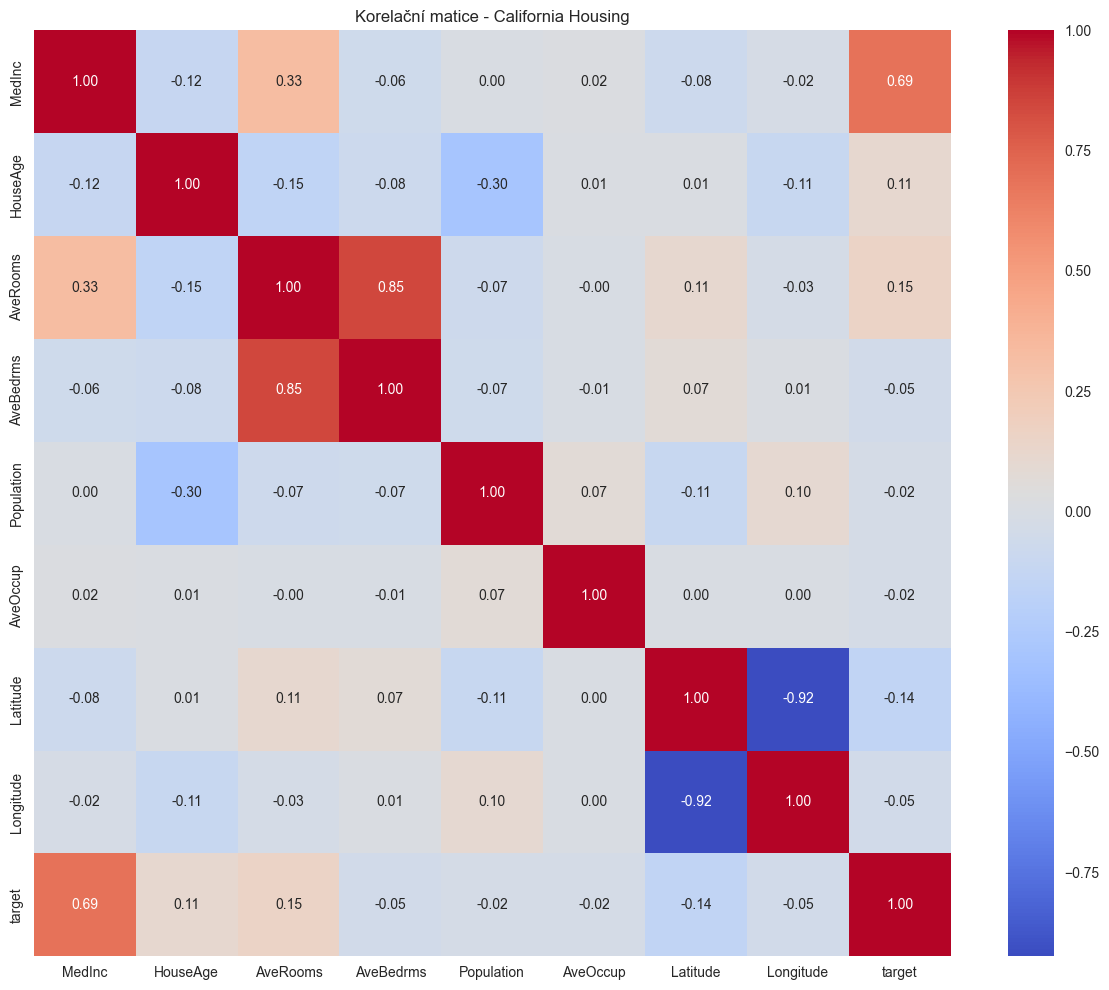


Základní statistiky datasetu:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude    target  
count  20640.00   20640.00  20640.00  
mean      35.63    -119.57      2.07  
std        2.14       2.00      1.15  
min       32.54    -124.35      0.15  
25%       33.93    -121.80      1.20  
50%       34.26    -118.49      1.80  
75%       37.71    -118.01      2.65  
max     

In [6]:
# Načtení datasetu California Housing
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Základní informace o datasetu
print(f"Tvar datasetu: {X_housing.shape}")
print(f"Příznaky: {housing.feature_names}")

# Rozdělení dat na trénovací a testovací
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42)

# Standardizace příznaků
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

# Analýza korelací v datasetu
housing_df = pd.DataFrame(X_housing, columns=housing.feature_names)
housing_df['target'] = y_housing
housing_corr = housing_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(housing_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelační matice - California Housing')
plt.tight_layout()
plt.show()

# Výpis základních statistik
print("\nZákladní statistiky datasetu:")
print(housing_df.describe().round(2))

In [7]:
# Porovnání různých regresních modelů
models = {
    'Lineární regrese': LinearRegression(),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=10000)
}

results = {}

for name, model in models.items():
    # Měření času trénování
    start_time = time.time()
    model.fit(X_train_h_scaled, y_train_h)
    train_time = time.time() - start_time
    
    # Predikce
    y_pred_train = model.predict(X_train_h_scaled)
    y_pred_test = model.predict(X_test_h_scaled)
    
    # Výpočet metrik
    train_mse = mean_squared_error(y_train_h, y_pred_train)
    test_mse = mean_squared_error(y_test_h, y_pred_test)
    test_r2 = r2_score(y_test_h, y_pred_test)
    
    # L2 norma koeficientů
    coef_norm = np.linalg.norm(model.coef_)
    
    results[name] = {
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Test R²': test_r2,
        'L2 norma koef.': coef_norm,
        'Čas trénování (s)': train_time
    }

# Výpis výsledků
results_df = pd.DataFrame(results).T
print("Výsledky regresních modelů:")
print(results_df.round(4))

Výsledky regresních modelů:
                    Train MSE  Test MSE  Test R²  L2 norma koef.  \
Lineární regrese       0.5179    0.5559   0.5758          1.5842   
Ridge (alpha=0.1)      0.5179    0.5559   0.5758          1.5841   
Ridge (alpha=1.0)      0.5179    0.5559   0.5758          1.5832   
Ridge (alpha=10.0)     0.5179    0.5555   0.5761          1.5745   
Lasso (alpha=0.1)      0.6718    0.6796   0.4814          0.7186   

                    Čas trénování (s)  
Lineární regrese               0.0078  
Ridge (alpha=0.1)              0.0040  
Ridge (alpha=1.0)              0.0034  
Ridge (alpha=10.0)             0.0033  
Lasso (alpha=0.1)              0.0073  


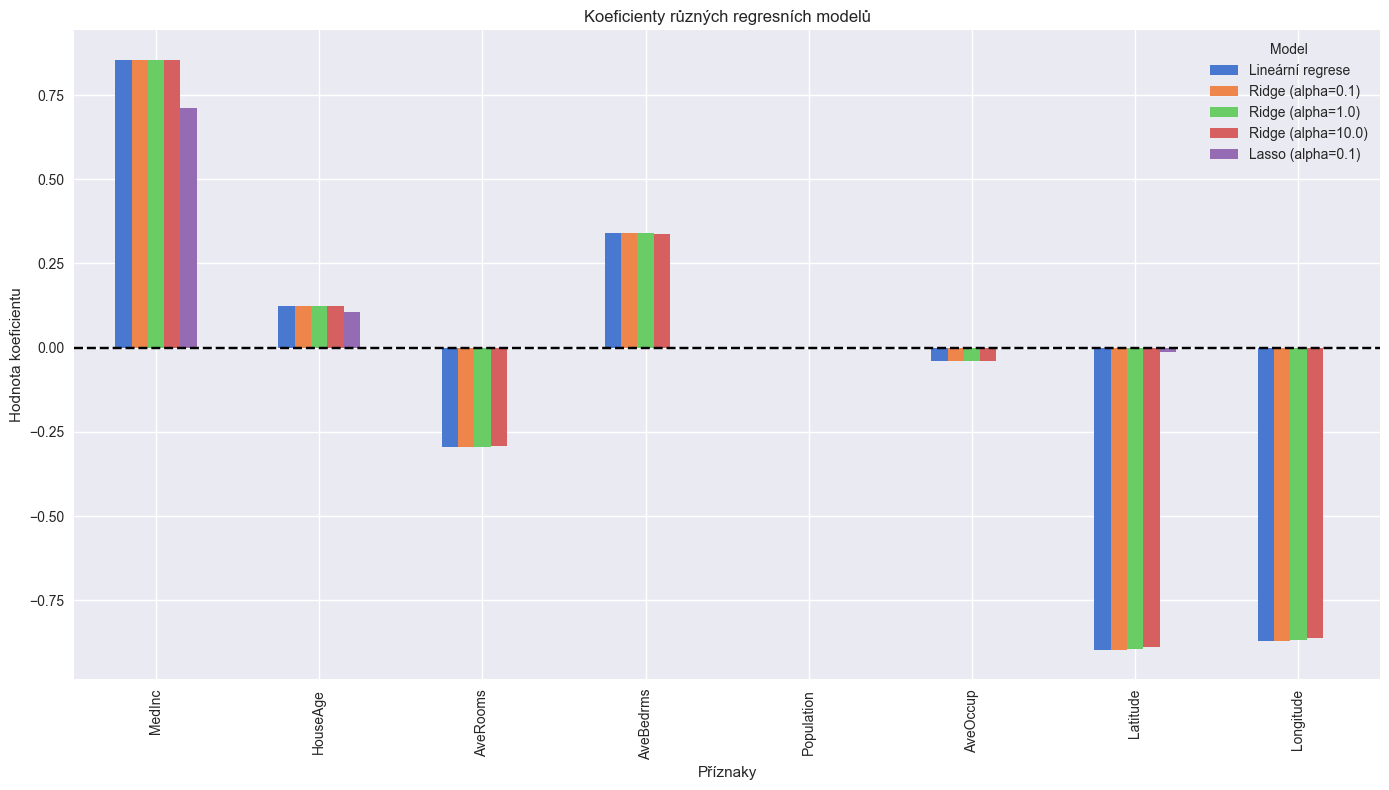

In [8]:
# Vizualizace koeficientů z různých modelů
coef_df = pd.DataFrame()

for name, model in models.items():
    coef_df[name] = model.coef_

# Přidání názvů příznaků
coef_df.index = housing.feature_names

# Vizualizace
plt.figure(figsize=(14, 8))
ax = coef_df.plot(kind='bar', ax=plt.gca())
plt.axhline(y=0, color='k', linestyle='--')
plt.title('Koeficienty různých regresních modelů')
plt.xlabel('Příznaky')
plt.ylabel('Hodnota koeficientu')
plt.legend(title='Model')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

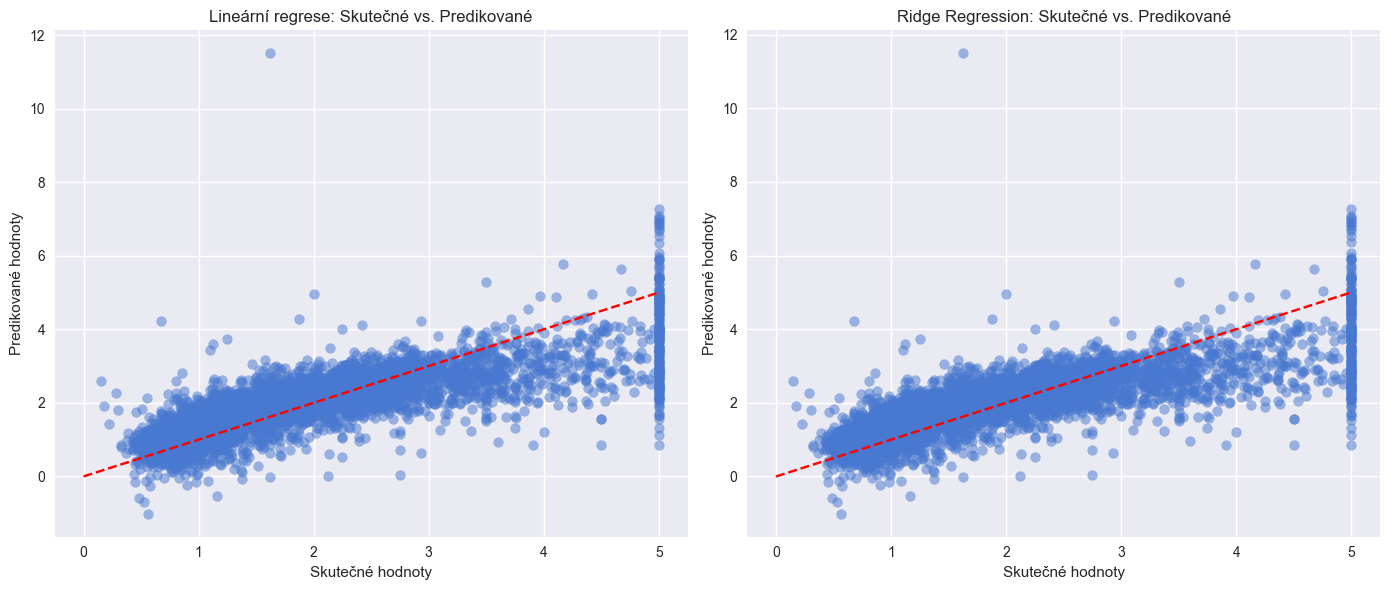

In [9]:
# Vizualizace skutečných vs. predikovaných hodnot
ridge_model = models['Ridge (alpha=1.0)']
y_pred_ridge = ridge_model.predict(X_test_h_scaled)
lr_model = models['Lineární regrese']
y_pred_lr = lr_model.predict(X_test_h_scaled)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test_h, y_pred_lr, alpha=0.5)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.title('Lineární regrese: Skutečné vs. Predikované')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_h, y_pred_ridge, alpha=0.5)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.title('Ridge Regression: Skutečné vs. Predikované')
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Hledání optimální hodnoty alpha pomocí cross-validace

Ridge regrese zahrnuje hyperparametr alpha, který je potřeba optimálně nastavit. Scikit-learn poskytuje `RidgeCV`, který automaticky provádí křížovou validaci pro hledání nejlepší hodnoty alpha.

In [10]:
# Definice rozsahu hodnot alpha pro testování
alphas_cv = np.logspace(-3, 3, 100)

# Inicializace RidgeCV
ridge_cv = RidgeCV(alphas=alphas_cv, scoring='neg_mean_squared_error', cv=5)

# Trénování modelu
ridge_cv.fit(X_train_h_scaled, y_train_h)

# Nejlepší hodnota alpha
print(f"Nejlepší hodnota alpha: {ridge_cv.alpha_:.6f}")

# Evaluace modelu s nejlepší hodnotou alpha
best_ridge = Ridge(alpha=ridge_cv.alpha_)
best_ridge.fit(X_train_h_scaled, y_train_h)
y_pred_best = best_ridge.predict(X_test_h_scaled)

best_mse = mean_squared_error(y_test_h, y_pred_best)
best_r2 = r2_score(y_test_h, y_pred_best)

print(f"MSE s optimálním alpha: {best_mse:.4f}")
print(f"R² s optimálním alpha: {best_r2:.4f}")

Nejlepší hodnota alpha: 0.114976
MSE s optimálním alpha: 0.5559
R² s optimálním alpha: 0.5758


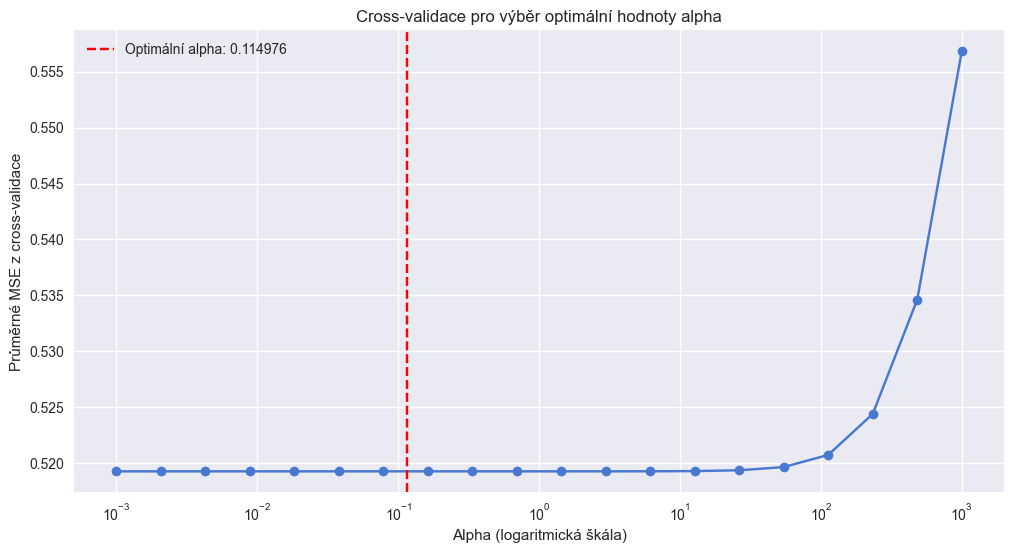

In [11]:
# Ruční cross-validace pro vizualizaci vlivu alpha na chybu
alphas_test = np.logspace(-3, 3, 20)
cv_scores = []

for alpha in alphas_test:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train_h_scaled, y_train_h,
                           scoring='neg_mean_squared_error', cv=5)
    cv_scores.append(-np.mean(scores))  # Převedení na pozitivní MSE

# Vykreslení křivky MSE vs. alpha
plt.figure(figsize=(12, 6))
plt.semilogx(alphas_test, cv_scores, 'o-')
plt.axvline(ridge_cv.alpha_, color='r', linestyle='--', 
            label=f'Optimální alpha: {ridge_cv.alpha_:.6f}')
plt.xlabel('Alpha (logaritmická škála)')
plt.ylabel('Průměrné MSE z cross-validace')
plt.title('Cross-validace pro výběr optimální hodnoty alpha')
plt.legend()
plt.grid(True)
plt.show()

## 4. Ridge Regression vs. Lasso: Kdy použít kterou metodu?

Pojďme porovnat výkon Ridge a Lasso regrese při různých scénářích.

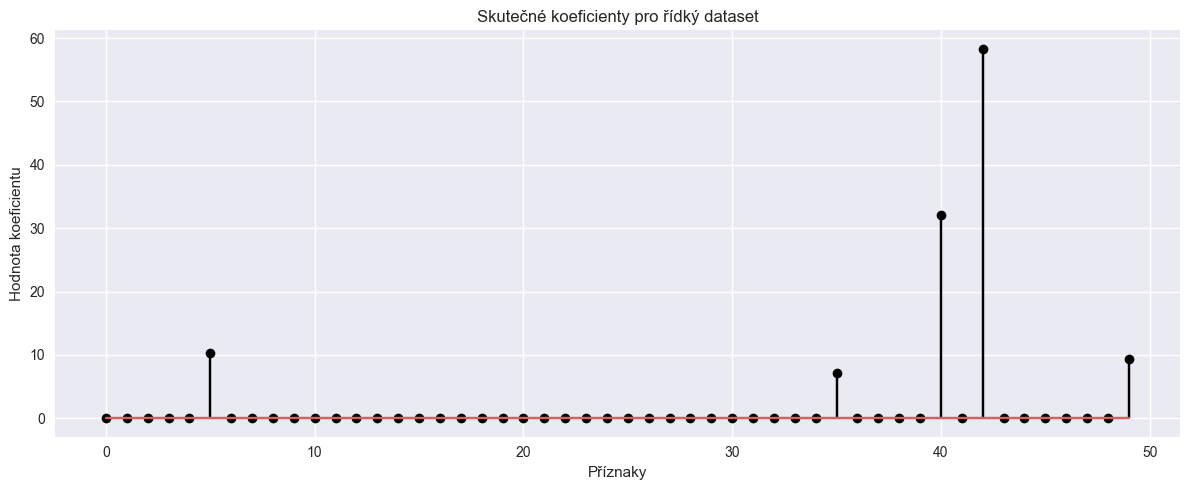

In [12]:
# Vytvoření datasetu s řídkou strukturou (sparse) - vhodné pro Lasso
def create_sparse_data(n_samples=200, n_features=50, n_informative=5, noise=1.0, random_state=42):
    """Vytvoří dataset, kde pouze několik příznaků má skutečný vliv"""
    X, y, coef = make_regression(n_samples=n_samples, 
                                n_features=n_features, 
                                n_informative=n_informative, 
                                noise=noise, 
                                coef=True,
                                random_state=random_state)
    
    return X, y, coef

# Vytvoření dat
X_sparse, y_sparse, true_coef = create_sparse_data(n_features=50, n_informative=5)
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(X_sparse, y_sparse, test_size=0.2, random_state=42)

# Standardizace
scaler_sp = StandardScaler()
X_train_sp_scaled = scaler_sp.fit_transform(X_train_sp)
X_test_sp_scaled = scaler_sp.transform(X_test_sp)

# Vizualizace skutečných koeficientů
plt.figure(figsize=(12, 5))
plt.stem(range(len(true_coef)), true_coef, 'k-', markerfmt='ko', label='Skutečné koeficienty')
plt.xlabel('Příznaky')
plt.ylabel('Hodnota koeficientu')
plt.title('Skutečné koeficienty pro řídký dataset')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Porovnání modelů na řídkých datech
models_sparse = {
    'Lineární regrese': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=10000),
}

coefs_sparse = {}
results_sparse = {}

for name, model in models_sparse.items():
    # Trénování
    model.fit(X_train_sp_scaled, y_train_sp)
    
    # Predikce
    y_pred = model.predict(X_test_sp_scaled)
    
    # Metriky
    mse = mean_squared_error(y_test_sp, y_pred)
    r2 = r2_score(y_test_sp, y_pred)
    
    # Počet nenulových koeficientů
    n_nonzero = np.sum(np.abs(model.coef_) > 1e-10)
    
    results_sparse[name] = {
        'MSE': mse,
        'R²': r2,
        'Nenulové koef.': n_nonzero
    }
    
    coefs_sparse[name] = model.coef_

# Výpis výsledků
results_sparse_df = pd.DataFrame(results_sparse).T
print("Výsledky na řídkých datech:")
print(results_sparse_df.round(4))

Výsledky na řídkých datech:
                      MSE      R²  Nenulové koef.
Lineární regrese   1.5236  0.9997            50.0
Ridge (alpha=1.0)  2.7211  0.9995            50.0
Lasso (alpha=0.1)  1.2616  0.9998            11.0


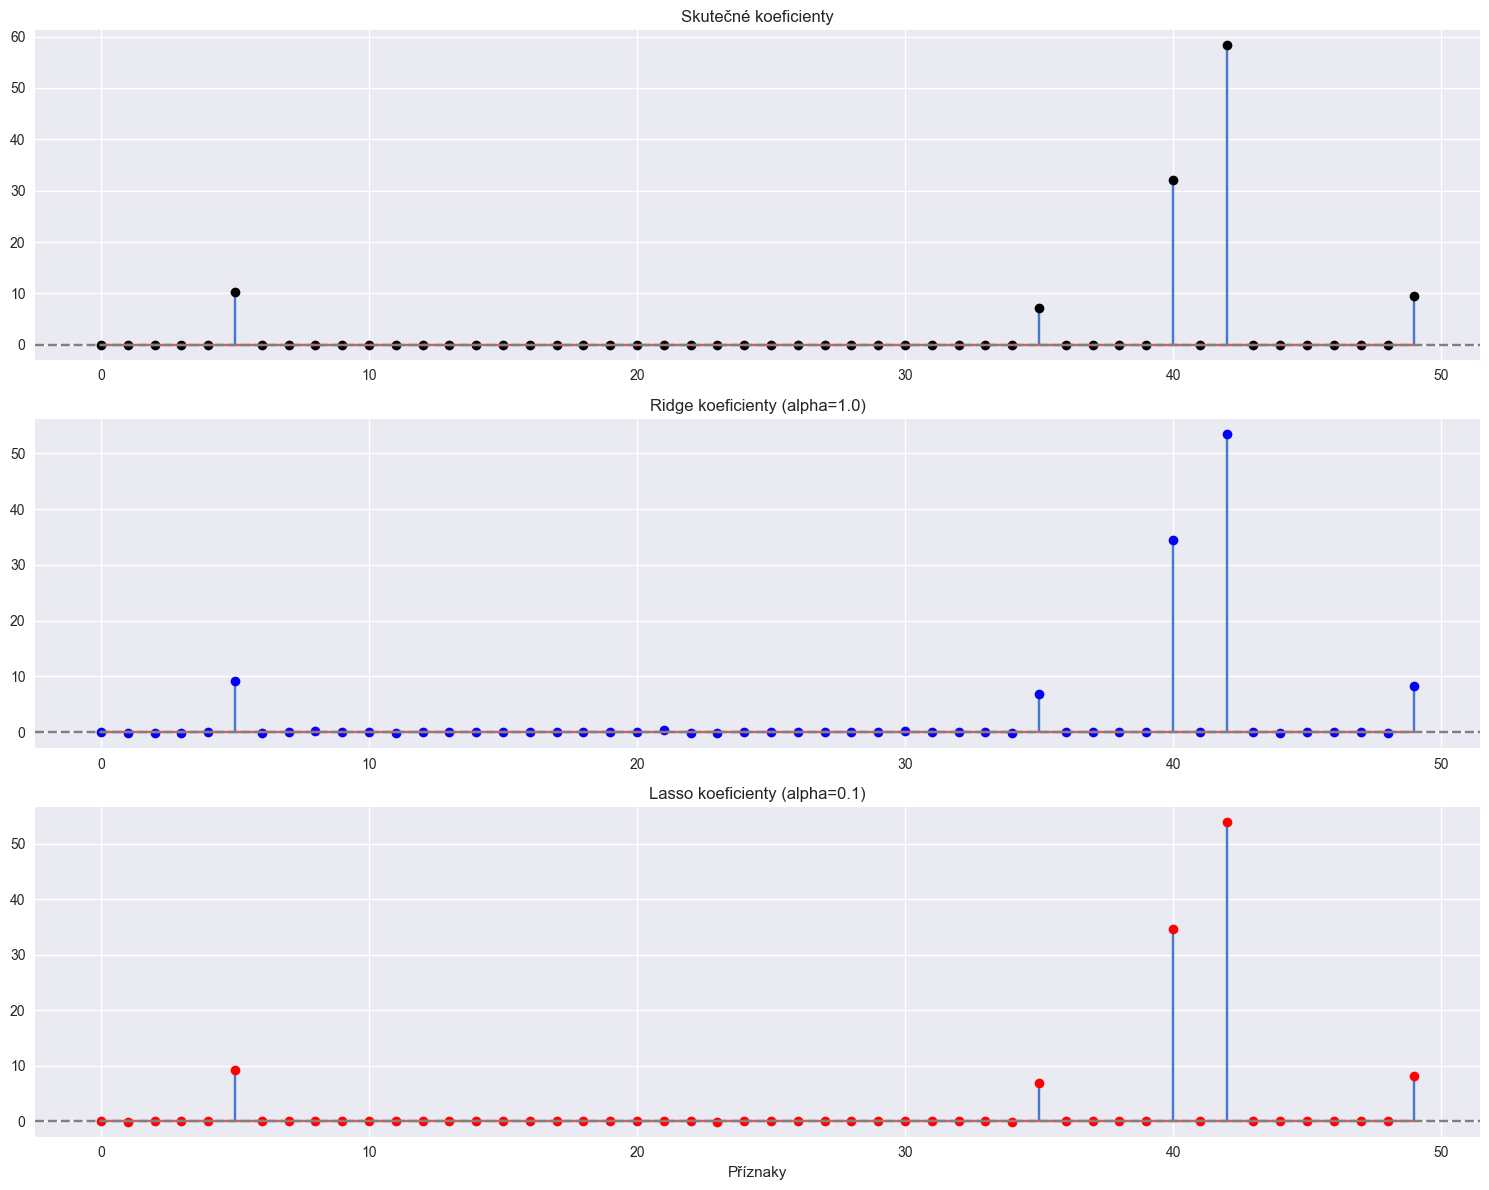

In [14]:
# Vizualizace koeficientů pro řídký dataset
plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.stem(range(len(true_coef)), true_coef, markerfmt='ko')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Skutečné koeficienty')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(range(len(coefs_sparse['Ridge (alpha=1.0)'])), coefs_sparse['Ridge (alpha=1.0)'], markerfmt='bo')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Ridge koeficienty (alpha=1.0)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(range(len(coefs_sparse['Lasso (alpha=0.1)'])), coefs_sparse['Lasso (alpha=0.1)'], markerfmt='ro')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Lasso koeficienty (alpha=0.1)')
plt.xlabel('Příznaky')
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Ridge Regression při přeučení s polynomiálními příznaky

Další běžnou aplikací Ridge regrese je při práci s polynomiálními příznaky, kde je vysoké riziko přeučení.

In [15]:
# Načtení menšího datasetu diabetes pro ukázku polynomiálních příznaků
diabetes = load_diabetes()
X_diabetes, y_diabetes = diabetes.data, diabetes.target

# Výběr pouze dvou příznaků pro lepší vizualizaci
X_simple = X_diabetes[:, :2]

# Rozdělení na trénovací a testovací data
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_simple, y_diabetes, test_size=0.2, random_state=42)

# Vytvoření polynomiálních příznaků pro demonstraci přeučení
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train_d)
X_test_poly = poly.transform(X_test_d)

print(f"Původní počet příznaků: {X_train_d.shape[1]}")
print(f"Počet polynomiálních příznaků: {X_train_poly.shape[1]}")

Původní počet příznaků: 2
Počet polynomiálních příznaků: 66


In [16]:
# Porovnání přeučení s polynomiálními příznaky
models_poly = {
    'Lineární regrese': LinearRegression(),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
}

results_poly = {}

for name, model in models_poly.items():
    # Trénování modelu
    model.fit(X_train_poly, y_train_d)
    
    # Predikce na trénovacích a testovacích datech
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Výpočet metrik
    train_mse = mean_squared_error(y_train_d, y_train_pred)
    test_mse = mean_squared_error(y_test_d, y_test_pred)
    r2 = r2_score(y_test_d, y_test_pred)
    
    results_poly[name] = {
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Test R²': r2,
        'Poměr Test/Train MSE': test_mse / train_mse
    }

# Výpis výsledků
results_poly_df = pd.DataFrame(results_poly).T
print("Výsledky s polynomiálními příznaky:")
print(results_poly_df.round(4))

Výsledky s polynomiálními příznaky:
                    Train MSE    Test MSE  Test R²  Poměr Test/Train MSE
Lineární regrese    5559.2608  17345.3605  -2.2739                3.1201
Ridge (alpha=0.1)   5840.1440   5276.5555   0.0041                0.9035
Ridge (alpha=1.0)   5917.2182   5247.8770   0.0095                0.8869
Ridge (alpha=10.0)  6044.5596   5333.5142  -0.0067                0.8824


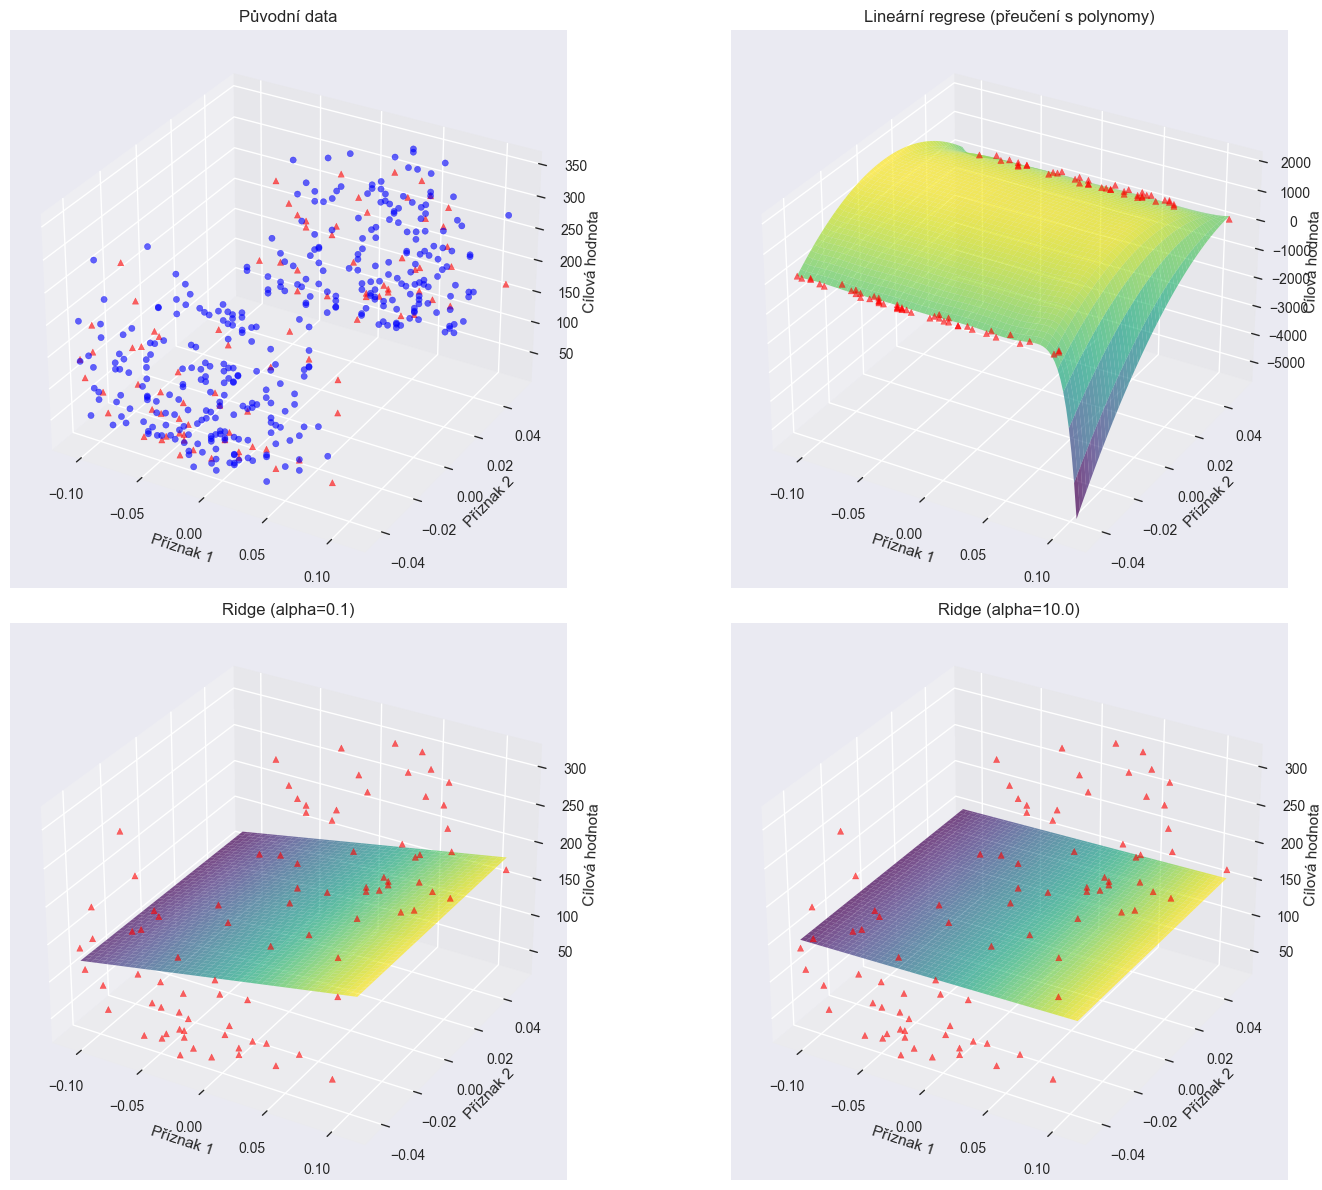

In [17]:
# Vizualizace přeučení a jeho potlačení pomocí Ridge regrese
# Vytvoříme spojitý rozsah hodnot pro predikce
x_range = np.linspace(X_simple[:, 0].min(), X_simple[:, 0].max(), 100)
y_range = np.linspace(X_simple[:, 1].min(), X_simple[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
X_grid = np.vstack([xx.ravel(), yy.ravel()]).T
X_grid_poly = poly.transform(X_grid)

# Vytvoření predikcí pro vizualizaci
grid_predictions = {}
for name, model in models_poly.items():
    grid_predictions[name] = model.predict(X_grid_poly).reshape(xx.shape)

# Vizualizace
fig = plt.figure(figsize=(16, 12))

# Původní data
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(X_train_d[:, 0], X_train_d[:, 1], y_train_d, c='b', marker='o', alpha=0.6)
ax1.scatter(X_test_d[:, 0], X_test_d[:, 1], y_test_d, c='r', marker='^', alpha=0.6)
ax1.set_xlabel('Příznak 1')
ax1.set_ylabel('Příznak 2')
ax1.set_zlabel('Cílová hodnota')
ax1.set_title('Původní data')

# Lineární regrese
ax2 = fig.add_subplot(222, projection='3d')
surf = ax2.plot_surface(xx, yy, grid_predictions['Lineární regrese'], cmap='viridis', alpha=0.7)
ax2.scatter(X_test_d[:, 0], X_test_d[:, 1], y_test_d, c='r', marker='^', alpha=0.6)
ax2.set_xlabel('Příznak 1')
ax2.set_ylabel('Příznak 2')
ax2.set_zlabel('Cílová hodnota')
ax2.set_title('Lineární regrese (přeučení s polynomy)')

# Ridge (alpha=0.1)
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(xx, yy, grid_predictions['Ridge (alpha=0.1)'], cmap='viridis', alpha=0.7)
ax3.scatter(X_test_d[:, 0], X_test_d[:, 1], y_test_d, c='r', marker='^', alpha=0.6)
ax3.set_xlabel('Příznak 1')
ax3.set_ylabel('Příznak 2')
ax3.set_zlabel('Cílová hodnota')
ax3.set_title('Ridge (alpha=0.1)')

# Ridge (alpha=10.0)
ax4 = fig.add_subplot(224, projection='3d')
surf = ax4.plot_surface(xx, yy, grid_predictions['Ridge (alpha=10.0)'], cmap='viridis', alpha=0.7)
ax4.scatter(X_test_d[:, 0], X_test_d[:, 1], y_test_d, c='r', marker='^', alpha=0.6)
ax4.set_xlabel('Příznak 1')
ax4.set_ylabel('Příznak 2')
ax4.set_zlabel('Cílová hodnota')
ax4.set_title('Ridge (alpha=10.0)')

plt.tight_layout()
plt.show()

## 6. Ridge Regression jako regularizovaná lineární regrese s Pipeline

Scikit-learn umožňuje snadno kombinovat Ridge regresi s různými transformacemi příznaků pomocí Pipeline.

In [18]:
# Vytvoření komplexního pipeline s polynomiálními příznaky a Ridge regresí
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('ridge', Ridge(alpha=1.0))
])

# Trénování pipeline
ridge_pipeline.fit(X_train_h, y_train_h)

# Predikce
y_pred_pipeline = ridge_pipeline.predict(X_test_h)
mse_pipeline = mean_squared_error(y_test_h, y_pred_pipeline)
r2_pipeline = r2_score(y_test_h, y_pred_pipeline)

print("Výsledky Pipeline s Ridge:")
print(f"MSE: {mse_pipeline:.4f}")
print(f"R²: {r2_pipeline:.4f}")

Výsledky Pipeline s Ridge:
MSE: 23.8223
R²: -17.1793


## 7. Shrnutí a nejlepší postupy pro použití Ridge Regression

### Kdy použít Ridge Regression:

1. **Při multikolinearitě** - Když máte mnoho korelovaných příznaků
2. **Pro prevenci přeučení** - Zejména při práci s polynomiálními nebo interakčními příznaky
3. **Když chcete zachovat všechny příznaky** - Na rozdíl od Lasso, Ridge zachovává všechny příznaky v modelu
4. **Pro stabilizaci koeficientů** - Když koeficienty standardní lineární regrese vykazují nestabilitu

### Srovnání s jinými metodami:

- **Ridge vs. Lineární regrese:** Ridge poskytuje stabilnější řešení, méně náchylné k přeučení, zejména při korelovaných příznacích
- **Ridge vs. Lasso:** Ridge zachovává všechny příznaky, zatímco Lasso nastavuje některé koeficienty přesně na nulu (provádí výběr příznaků)
- **Ridge vs. ElasticNet:** ElasticNet kombinuje vlastnosti Ridge a Lasso, poskytuje kompromis mezi výběrem příznaků a stabilizací koeficientů

### Praktické tipy:

1. **Vždy standardizujte data** před aplikací Ridge regrese, protože regularizace je citlivá na měřítko příznaků
2. **Použijte cross-validaci** (RidgeCV) pro nalezení optimální hodnoty alpha
3. **Experimentujte s různými hodnotami alpha** a sledujte, jak ovlivňují velikost koeficientů a výkon modelu
4. **Vizualizujte koeficienty** pro různé hodnoty alpha, abyste lépe pochopili vliv regularizace
5. **Kombinujte Ridge s polynomiálními příznaky** pro modelování nelineárních vztahů bez přeučení

### Silné stránky Ridge Regression:

- Efektivně řeší multikolinearitu
- Prevence přeučení
- Stabilita koeficientů
- Zachovává všechny příznaky v modelu
- Má uzavřené analytické řešení (na rozdíl od Lasso)

### Slabé stránky Ridge Regression:

- Neprovádí výběr příznaků (všechny příznaky zůstávají v modelu)
- Vyžaduje ladění hyperparametru alpha
- Není vhodná, když je mnoho příznaků irelevantních (v takovém případě je lepší Lasso)

Ridge regrese je silný nástroj pro vytváření stabilních lineárních modelů s dobrou schopností generalizace, zejména při práci s korelovanými příznaky nebo při riziku přeučení.